In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## What is persistent
- dataset manifests
- split manifests
- clip metadata
- MFCC feature cache
- sklearn-ready flattened arrays
- fitted scalers
- trained models
- evaluation JSON files


In [2]:
# Optional: install missing dependencies
# Uncomment if needed in a fresh Colab runtime
%pip -q install librosa soundfile scikit-learn joblib tqdm kagglehub pandas


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Optional: mount Google Drive in Colab for persistence across runtime sessions
# Run this in Colab. If you are local, skip this cell and set PROJECT_ROOT below.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Skipping Drive mount:", e)

Skipping Drive mount: No module named 'google.colab'


## Config

Set `PROJECT_ROOT` to a persistent location.
- Colab + Drive : `/content/drive/MyDrive/pf2_speech_baseline`

In [4]:
import os
import json
import math
import time
import hashlib
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Optional

import joblib
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

@dataclass
class Config:
    # persistence root
    PROJECT_ROOT: str = ""

    # dataset path where the pre-split for-norm dataset should live persistently
    DATA_ROOT: str = "/home/dbpatel5/Downloads/NN/data"

    # if DATA_ROOT is missing on first run, download from Kaggle and copy it there
    AUTO_DOWNLOAD_WITH_KAGGLEHUB: bool = True
    KAGGLE_DATASET_ID: str = "mohammedabdeldayem/the-fake-or-real-dataset"

    # audio + MFCC
    SAMPLE_RATE: int = 16000
    CLIP_SECONDS: float = 4.0
    N_MFCC: int = 40
    N_FFT: int = 1024
    HOP_LENGTH: int = 256
    WIN_LENGTH: int = 1024
    FMIN: int = 20
    FMAX: int = 7600

    # feature representation
    # "flatten" is good for LR / SVM
    # "stats" gives mean+std over time and is much smaller
    FEATURE_VIEW: str = "flatten"

    # logistic regression baseline
    LR_C: float = 1.0
    LR_MAX_ITER: int = 2000

cfg = Config()

PROJECT_ROOT = Path(cfg.PROJECT_ROOT)
DATA_ROOT = Path(cfg.DATA_ROOT)

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MANIFEST_DIR = ARTIFACTS_DIR / "manifests"
META_DIR = ARTIFACTS_DIR / "metadata"
FEATURE_DIR = ARTIFACTS_DIR / "features"
ARRAY_DIR = ARTIFACTS_DIR / "arrays"
MODEL_DIR = ARTIFACTS_DIR / "models"
METRIC_DIR = ARTIFACTS_DIR / "metrics"

for d in [PROJECT_ROOT, ARTIFACTS_DIR, MANIFEST_DIR, META_DIR, FEATURE_DIR, ARRAY_DIR, MODEL_DIR, METRIC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

MAX_LEN_SAMPLES = int(cfg.SAMPLE_RATE * cfg.CLIP_SECONDS)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_ROOT    =", DATA_ROOT)
print("MAX_LEN_SAMPLES =", MAX_LEN_SAMPLES)

PROJECT_ROOT = .
DATA_ROOT    = /home/dbpatel5/Downloads/NN/data
MAX_LEN_SAMPLES = 64000


## Dataset acquisition

This is only used once. After the dataset is placed in a persistent folder, future runtime sessions reuse it.

In [11]:
if not DATA_ROOT.exists() and cfg.AUTO_DOWNLOAD_WITH_KAGGLEHUB:
    import kagglehub
    download_root = Path(kagglehub.dataset_download(cfg.KAGGLE_DATASET_ID))
    print("Downloaded to:", download_root)

    # Try common location for the for-norm subset
    candidate = download_root / "for-norm"
    if candidate.exists():
        DATA_ROOT = candidate
        print("Using:", DATA_ROOT)
    else:
        print("Please inspect downloaded files and set cfg.DATA_ROOT manually.")
else:
    print("Skipping download. Existing DATA_ROOT:", DATA_ROOT.exists())

Skipping download. Existing DATA_ROOT: True


In [12]:
import os
from pathlib import Path

download_root = Path("/home/dbpatel5/Downloads/NN/data")

for_norm_path = None

for dirpath, _, _ in os.walk(download_root):
    p = Path(dirpath)

    # must contain 'for-norm' in path
    if "for-norm" in str(p).lower():
        if all((p / x).exists() for x in ["training", "validation", "testing"]):
            for_norm_path = p
            print("FOUND for-norm:", for_norm_path)
            break

if for_norm_path is None:
    raise FileNotFoundError("Could not find for-norm dataset inside download")

FOUND for-norm: /home/dbpatel5/Downloads/NN/data/for-norm/for-norm


In [14]:
# !cp -r "/root/.cache/kagglehub/datasets/mohammedabdeldayem/the-fake-or-real-dataset/versions/2/for-norm/for-norm" "/content/drive/MyDrive/pf2_speech_baseline/data/"

## Dataset setup

In [5]:
import shutil

def dataset_has_expected_structure(root: Path) -> bool:
    expected_dirs = [
        root / "training" / "real",
        root / "training" / "fake",
        root / "validation" / "real",
        root / "validation" / "fake",
        root / "testing" / "real",
        root / "testing" / "fake",
    ]
    return all(p.exists() for p in expected_dirs)

def find_for_norm_root(download_root: Path) -> Path:
    if dataset_has_expected_structure(download_root):
        return download_root

    for dirpath, _, _ in os.walk(download_root):
        candidate = Path(dirpath)
        if dataset_has_expected_structure(candidate):
            return candidate

    raise FileNotFoundError(f"Could not find pre-split for-norm folder inside: {download_root}")

if dataset_has_expected_structure(DATA_ROOT):
    print(f"Using existing dataset at: {DATA_ROOT}")
else:
    if not cfg.AUTO_DOWNLOAD_WITH_KAGGLEHUB:
        raise FileNotFoundError(f"Dataset missing at {DATA_ROOT} and auto-download is disabled.")

    print("Dataset not found. Downloading from Kaggle...")
    import kagglehub

    downloaded_path = Path(kagglehub.dataset_download(cfg.KAGGLE_DATASET_ID))
    print("Downloaded to:", downloaded_path)

    source_root = find_for_norm_root(downloaded_path)
    print("Found dataset root:", source_root)

    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)

    if DATA_ROOT.exists():
        shutil.rmtree(DATA_ROOT)

    shutil.copytree(source_root, DATA_ROOT)
    print("Copied dataset to persistent location:", DATA_ROOT)

print("Dataset ready:", DATA_ROOT)

Using existing dataset at: /home/dbpatel5/Downloads/NN/data
Dataset ready: /home/dbpatel5/Downloads/NN/data


## Dataset inspection

This cell avoids hardcoding `/training/real` unless that structure actually exists.

In [6]:
AUDIO_EXTS = {".wav", ".flac", ".mp3", ".ogg", ".m4a"}

def quick_tree(root: Path, depth: int = 2, max_children: int = 8):
    root = Path(root)
    if not root.exists():
        print("Path does not exist:", root)
        return
    print(f"Inspecting: {root}")
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        level = len(rel.parts)
        if level > depth:
            continue
        indent = "  " * (level - 1)
        print(f"{indent}- {rel}{'/' if p.is_dir() else ''}")

quick_tree(DATA_ROOT, depth=2)

Inspecting: /home/dbpatel5/Downloads/NN/data
- testing/
  - testing/fake/
  - testing/real/
- training/
  - training/fake/
  - training/real/
- validation/
  - validation/fake/
  - validation/real/


## Build one reusable raw manifest

This is heavy but persistent stage.  
It scans the dataset once and saves a CSV with:
- filepath
- label
- source split if one already exists in the folders
- file size

The scanner supports:
- `for-norm/training/real/...`, `validation/...`, `testing/...`

In [7]:
def infer_label_from_parts(parts):
    lowered = [p.lower() for p in parts]
    if "real" in lowered:
        return 0
    if "fake" in lowered:
        return 1
    return None

def infer_existing_split_from_parts(parts):
    lowered = [p.lower() for p in parts]

    if len(lowered) == 0:
        return None

    top = lowered[0]

    if top in ["train", "training"]:
        return "train"
    if top in ["val", "valid", "validation", "dev"]:
        return "val"
    if top in ["test", "testing"]:
        return "test"

    return None

raw_manifest_path = MANIFEST_DIR / "raw_manifest.csv"

def build_raw_manifest(data_root: Path) -> pd.DataFrame:
    rows = []
    for fp in sorted(data_root.rglob("*")):
        if not fp.is_file() or fp.suffix.lower() not in AUDIO_EXTS:
            continue
        parts = fp.relative_to(data_root).parts
        label = infer_label_from_parts(parts)
        if label is None:
            continue
        rows.append({
            "filepath": str(fp),
            "label": label,  # 0=real, 1=fake
            "existing_split": infer_existing_split_from_parts(parts),
            "filesize_bytes": fp.stat().st_size
        })
    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No labeled audio files found under {data_root}")
    return df

if raw_manifest_path.exists():
    raw_df = pd.read_csv(raw_manifest_path)
    print("Loaded existing raw manifest:", raw_manifest_path)
else:
    raw_df = build_raw_manifest(DATA_ROOT)
    raw_df.to_csv(raw_manifest_path, index=False)
    print("Built and saved raw manifest:", raw_manifest_path)

print(raw_df.head())
print("\nClass counts:")
print(raw_df["label"].value_counts().sort_index().rename(index={0: "real", 1: "fake"}))
print("\nExisting split counts:")
print(raw_df["existing_split"].fillna("none").value_counts())

Loaded existing raw manifest: artifacts/manifests/raw_manifest.csv
                                            filepath  label existing_split  \
0  /home/dbpatel5/Downloads/NN/data/testing/fake/...      1           test   
1  /home/dbpatel5/Downloads/NN/data/testing/fake/...      1           test   
2  /home/dbpatel5/Downloads/NN/data/testing/fake/...      1           test   
3  /home/dbpatel5/Downloads/NN/data/testing/fake/...      1           test   
4  /home/dbpatel5/Downloads/NN/data/testing/fake/...      1           test   

   filesize_bytes  
0           64044  
1           64044  
2           64044  
3           64044  
4           64044  

Class counts:
label
real    8935
fake    8935
Name: count, dtype: int64

Existing split counts:
existing_split
train    13956
val       2826
test      1088
Name: count, dtype: int64


## 5) Build persistent train / val / test manifests

Rules:
- If the dataset already contains train/val/test folders, reuse them directly.
- Otherwise create a stratified split once and save it.

In [8]:
train_manifest_path = MANIFEST_DIR / "train_manifest.csv"
val_manifest_path = MANIFEST_DIR / "val_manifest.csv"
test_manifest_path = MANIFEST_DIR / "test_manifest.csv"

def make_or_load_split_manifests(raw_df: pd.DataFrame):
    if train_manifest_path.exists() and val_manifest_path.exists() and test_manifest_path.exists():
        train_df = pd.read_csv(train_manifest_path)
        val_df = pd.read_csv(val_manifest_path)
        test_df = pd.read_csv(test_manifest_path)
        print("Loaded existing split manifests.")
        return train_df, val_df, test_df

    # ONLY use existing folder structure
    train_df = raw_df[raw_df["existing_split"] == "train"].copy()
    val_df = raw_df[raw_df["existing_split"] == "val"].copy()
    test_df = raw_df[raw_df["existing_split"] == "test"].copy()

    if train_df.empty or val_df.empty or test_df.empty:
        raise ValueError(
            "Expected pre-split folders (training/validation/testing) not detected correctly."
        )

    train_df.to_csv(train_manifest_path, index=False)
    val_df.to_csv(val_manifest_path, index=False)
    test_df.to_csv(test_manifest_path, index=False)

    print("Saved split manifests from existing dataset folders.")
    return train_df, val_df, test_df

train_df, val_df, test_df = make_or_load_split_manifests(raw_df)

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = df["label"].value_counts().sort_index().to_dict()
    print(f"{name}: n={len(df)}, counts={{real:{counts.get(0,0)}, fake:{counts.get(1,0)}}}")

Loaded existing split manifests.
train: n=13956, counts={real:6978, fake:6978}
val: n=2826, counts={real:1413, fake:1413}
test: n=1088, counts={real:544, fake:544}


## 7) Feature-set identity

Every MFCC configuration gets its own cache directory.  
That means you can change `N_MFCC`, `CLIP_SECONDS`, `HOP_LENGTH`, etc. and the notebook will build a **new feature cache** without overwriting the old one.

In [9]:
import time
import json
import hashlib
from pathlib import Path

feature_config = {
    "sample_rate": cfg.SAMPLE_RATE,
    "clip_seconds": cfg.CLIP_SECONDS,
    "n_mfcc": cfg.N_MFCC,
    "n_fft": cfg.N_FFT,
    "hop_length": cfg.HOP_LENGTH,
    "win_length": cfg.WIN_LENGTH,
    "fmin": cfg.FMIN,
    "fmax": cfg.FMAX,
}

feature_key = hashlib.md5(json.dumps(feature_config, sort_keys=True).encode()).hexdigest()[:12]
feature_set_dir = FEATURE_DIR / f"mfcc_{feature_key}"
feature_set_dir.mkdir(parents=True, exist_ok=True)

feature_config_path = feature_set_dir / "feature_config.json"

for attempt in range(5):
    try:
        with open(feature_config_path, "w") as f:
            json.dump(feature_config, f, indent=2)
        print("Saved feature config:", feature_config_path)
        break

    except OSError as e:
        print(f"Drive write failed on attempt {attempt + 1}/5:", repr(e))
        time.sleep(5)

else:
    print("Could not write feature_config.json to Drive.")
    print("Continuing anyway because this file is only metadata.")

print("Feature cache:", feature_set_dir)
print(json.dumps(feature_config, indent=2))

Saved feature config: artifacts/features/mfcc_4db0f011b9c0/feature_config.json
Feature cache: artifacts/features/mfcc_4db0f011b9c0
{
  "sample_rate": 16000,
  "clip_seconds": 4.0,
  "n_mfcc": 40,
  "n_fft": 1024,
  "hop_length": 256,
  "win_length": 1024,
  "fmin": 20,
  "fmax": 7600
}


## 8) Persistent MFCC extraction

This is the expensive stage you do not want to repeat.

Strategy:
- one `.npy` file per audio clip
- filename derived from the absolute filepath hash
- reruns only compute missing features

In [10]:
!pip install tqdm
# import librosa
# from tqdm import tqdm

# def file_hash(path: str) -> str:
#     return hashlib.md5(path.encode()).hexdigest()

# def feature_path_for_audio(path: str) -> Path:
#     return feature_set_dir / f"{file_hash(path)}.npy"

# def load_audio_fixed_length(filepath, sr, max_len):
#     y, _ = librosa.load(filepath, sr=sr, mono=True)
#     if len(y) < max_len:
#         y = np.pad(y, (0, max_len - len(y)))
#     else:
#         y = y[:max_len]
#     return y.astype(np.float32)

# def compute_mfcc(filepath: str) -> np.ndarray:
#     y = load_audio_fixed_length(filepath, cfg.SAMPLE_RATE, MAX_LEN_SAMPLES)
#     mfcc = librosa.feature.mfcc(
#         y=y,
#         sr=cfg.SAMPLE_RATE,
#         n_mfcc=cfg.N_MFCC,
#         n_fft=cfg.N_FFT,
#         hop_length=cfg.HOP_LENGTH,
#         win_length=cfg.WIN_LENGTH,
#         fmin=cfg.FMIN,
#         fmax=cfg.FMAX,
#     )
#     return mfcc.astype(np.float32)

# def materialize_feature_cache(manifest_df: pd.DataFrame, split_name: str):
#     missing = []
#     for fp in manifest_df["filepath"]:
#         out = feature_path_for_audio(fp)
#         if not out.exists():
#             missing.append(fp)

#     print(f"{split_name}: cached={len(manifest_df) - len(missing)}, missing={len(missing)}")
#     for fp in tqdm(missing, desc=f"Caching MFCCs for {split_name}"):
#         mfcc = compute_mfcc(fp)
#         np.save(feature_path_for_audio(fp), mfcc)

# for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
#     materialize_feature_cache(df, split_name)


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import librosa
from tqdm.auto import tqdm
import pandas as pd
import numpy as np
import hashlib
from pathlib import Path

def file_hash(path: str) -> str:
    return hashlib.md5(path.encode()).hexdigest()

def feature_path_for_audio(path: str) -> Path:
    return feature_set_dir / f"{file_hash(path)}.npy"

def load_audio_fixed_length(filepath, sr, max_len):
    y, _ = librosa.load(filepath, sr=sr, mono=True)

    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    return y.astype(np.float32)

def compute_mfcc(filepath: str) -> np.ndarray:
    y = load_audio_fixed_length(filepath, cfg.SAMPLE_RATE, MAX_LEN_SAMPLES)

    mfcc = librosa.feature.mfcc(
        y=y,
        sr=cfg.SAMPLE_RATE,
        n_mfcc=cfg.N_MFCC,
        n_fft=cfg.N_FFT,
        hop_length=cfg.HOP_LENGTH,
        win_length=cfg.WIN_LENGTH,
        fmin=cfg.FMIN,
        fmax=cfg.FMAX,
    )

    return mfcc.astype(np.float32)

def materialize_feature_cache(manifest_df: pd.DataFrame, split_name: str):
    bad_rows = []

    missing = []
    for fp in manifest_df["filepath"]:
        out = feature_path_for_audio(fp)
        if not out.exists():
            missing.append(fp)

    print(f"{split_name}: cached={len(manifest_df) - len(missing)}, missing={len(missing)}")

    for fp in tqdm(missing, desc=f"Caching MFCCs for {split_name}"):
        try:
            mfcc = compute_mfcc(fp)
            np.save(feature_path_for_audio(fp), mfcc)

        except Exception as e:
            bad_rows.append({
                "split": split_name,
                "filepath": fp,
                "error": repr(e),
            })
            continue

    if bad_rows:
        bad_df = pd.DataFrame(bad_rows)
        bad_log_path = feature_set_dir / f"bad_audio_{split_name}.csv"
        bad_df.to_csv(bad_log_path, index=False)
        print(f"{split_name}: skipped {len(bad_rows)} bad files")
        print(f"Bad audio log saved to: {bad_log_path}")

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    materialize_feature_cache(df, split_name)

train: cached=13956, missing=0


Caching MFCCs for train: 0it [00:00, ?it/s]


val: cached=2826, missing=0


Caching MFCCs for val: 0it [00:00, ?it/s]


test: cached=1088, missing=0


Caching MFCCs for test: 0it [00:00, ?it/s]


In [12]:
def keep_only_cached_features(df):
    return df[df["filepath"].apply(lambda fp: feature_path_for_audio(fp).exists())].reset_index(drop=True)

train_df = keep_only_cached_features(train_df)
val_df = keep_only_cached_features(val_df)
test_df = keep_only_cached_features(test_df)

print("After removing bad/missing audio:")
print("train:", len(train_df))
print("val:", len(val_df))
print("test:", len(test_df))

After removing bad/missing audio:
train: 13956
val: 2826
test: 1088


## 9) Build reusable model arrays

This stage converts cached MFCC files into arrays that can be reused by many models.

Two views are supported:
- `flatten`: full MFCC image flattened to a vector
- `stats`: mean and std over time for a much smaller feature vector

In [13]:
def mfcc_to_vector(mfcc: np.ndarray, view: str) -> np.ndarray:
    if view == "flatten":
        return mfcc.reshape(-1).astype(np.float32)
    if view == "stats":
        mean = mfcc.mean(axis=1)
        std = mfcc.std(axis=1)
        return np.concatenate([mean, std]).astype(np.float32)
    raise ValueError(f"Unknown FEATURE_VIEW: {view}")

array_dir = ARRAY_DIR / f"mfcc_{feature_key}_{cfg.FEATURE_VIEW}"
array_dir.mkdir(parents=True, exist_ok=True)

def array_paths(split_name: str):
    return (
        array_dir / f"X_{split_name}.npy",
        array_dir / f"y_{split_name}.npy",
    )

def build_arrays_from_manifest(manifest_df: pd.DataFrame, split_name: str):
    X_path, y_path = array_paths(split_name)
    if X_path.exists() and y_path.exists():
        X = np.load(X_path, mmap_mode="r")
        y = np.load(y_path, mmap_mode="r")
        print(f"Loaded existing arrays for {split_name}: {X.shape}, {y.shape}")
        return X, y

    X_rows = []
    y_rows = []
    for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc=f"Building {split_name} arrays"):
        mfcc = np.load(feature_path_for_audio(row["filepath"]))
        vec = mfcc_to_vector(mfcc, cfg.FEATURE_VIEW)
        X_rows.append(vec)
        y_rows.append(int(row["label"]))

    X = np.stack(X_rows).astype(np.float32)
    y = np.array(y_rows, dtype=np.int64)

    np.save(X_path, X)
    np.save(y_path, y)
    print(f"Saved arrays for {split_name}: {X.shape}, {y.shape}")
    return X, y

X_train, y_train = build_arrays_from_manifest(train_df, "train")
X_val, y_val = build_arrays_from_manifest(val_df, "val")
X_test, y_test = build_arrays_from_manifest(test_df, "test")

Loaded existing arrays for train: (13956, 10040), (13956,)
Loaded existing arrays for val: (2826, 10040), (2826,)
Loaded existing arrays for test: (1088, 10040), (1088,)


## 10) Train-only normalization, saved once

The scaler is fitted only on the training split and reused later for all classical models that need it.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler_path = MODEL_DIR / f"scaler_{feature_key}_{cfg.FEATURE_VIEW}.joblib"

if scaler_path.exists():
    scaler = joblib.load(scaler_path)
    print("Loaded existing scaler:", scaler_path)
else:
    scaler = StandardScaler()
    scaler.fit(np.asarray(X_train))
    joblib.dump(scaler, scaler_path)
    print("Saved scaler:", scaler_path)

X_train_scaled = scaler.transform(np.asarray(X_train))
X_val_scaled = scaler.transform(np.asarray(X_val))
X_test_scaled = scaler.transform(np.asarray(X_test))
print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

Loaded existing scaler: artifacts/models/scaler_4db0f011b9c0_flatten.joblib
(13956, 10040) (2826, 10040) (1088, 10040)


## 11) Metrics helper

In [15]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

def compute_metrics(y_true, y_pred, y_score):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_score)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr_human_as_fake = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    return {
        "accuracy": float(acc),
        "precision_fake": float(precision),
        "recall_fake": float(recall),
        "f1_fake": float(f1),
        "roc_auc": float(roc_auc),
        "false_positive_rate_human_as_fake": float(fpr_human_as_fake),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def save_json(obj, path: Path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

## 12) Logistic Regression baseline

This stage is also persistent:
- if the model and metrics already exist, load them
- otherwise train and save them

You can clone this pattern for SVM, Random Forest, XGBoost, or a PyTorch model while reusing the same manifests and feature cache.

In [26]:
from sklearn.linear_model import LogisticRegression

model_name = f"logreg_C{cfg.LR_C}_{feature_key}_{cfg.FEATURE_VIEW}"
model_path = MODEL_DIR / f"{model_name}.joblib"
val_metric_path = METRIC_DIR / f"{model_name}_val.json"
test_metric_path = METRIC_DIR / f"{model_name}_test.json"

if model_path.exists() and val_metric_path.exists() and test_metric_path.exists():
    model = joblib.load(model_path)
    val_metrics = json.load(open(val_metric_path))
    test_metrics = json.load(open(test_metric_path))
    print("Loaded existing model and metrics.")
else:
    model = LogisticRegression(
        C=cfg.LR_C,
        max_iter=cfg.LR_MAX_ITER,
        solver="saga",
        random_state=SEED,
        n_jobs=-1
    )
    model.fit(X_train_scaled, y_train)

    val_prob = model.predict_proba(X_val_scaled)[:, 1]
    val_pred = (val_prob >= 0.5).astype(int)
    val_metrics = compute_metrics(y_val, val_pred, val_prob)

    test_prob = model.predict_proba(X_test_scaled)[:, 1]
    test_pred = (test_prob >= 0.5).astype(int)
    test_metrics = compute_metrics(y_test, test_pred, test_prob)

    joblib.dump(model, model_path)
    save_json(val_metrics, val_metric_path)
    save_json(test_metrics, test_metric_path)
    print("Trained and saved model + metrics.")

print("Validation metrics")
print(json.dumps(val_metrics, indent=2))
print("\nTest metrics")
print(json.dumps(test_metrics, indent=2))

: 

: 

## Pytorch Models

### Shared PyTorch setup

In [16]:
%pip install torch

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
import numpy as np
import json
import time

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

N_MFCC = cfg.N_MFCC
N_FRAMES = X_train_scaled.shape[1] // N_MFCC
print("MFCC shape per sample:", N_MFCC, "x", N_FRAMES)

def to_mfcc_tensor(X):
    X = np.asarray(X, dtype=np.float32)
    X = X.reshape(len(X), 1, N_MFCC, N_FRAMES)
    return torch.tensor(X, dtype=torch.float32)

Xtr_t = to_mfcc_tensor(X_train_scaled)
Xva_t = to_mfcc_tensor(X_val_scaled)
Xte_t = to_mfcc_tensor(X_test_scaled)

ytr_t = torch.tensor(np.asarray(y_train), dtype=torch.float32)
yva_t = torch.tensor(np.asarray(y_val), dtype=torch.float32)
yte_t = torch.tensor(np.asarray(y_test), dtype=torch.float32)

BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(Xtr_t, ytr_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    TensorDataset(Xva_t, yva_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    TensorDataset(Xte_t, yte_t),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

pos_count = float(np.sum(y_train == 1))
neg_count = float(np.sum(y_train == 0))
pos_weight = torch.tensor([neg_count / max(pos_count, 1.0)], device=DEVICE)
print("pos_weight:", pos_weight.item())


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
DEVICE: cuda
MFCC shape per sample: 40 x 251
pos_weight: 1.0


In [19]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

2.11.0+cu126
True
12.6
1
NVIDIA GeForce RTX 3060


In [ ]:
# !pip uninstall -y torch torchvision torchaudio
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Looking in indexes: https://download.pytorch.org/whl/cu126
  Obtaining dependency information for torch from https://download-r2.pytorch.org/whl/cu126/torch-2.11.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for torchvision from https://download-r2.pytorch.org/whl/cu126/torchvision-0.26.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for torchaudio from https://download-r2.pytorch.org/whl/cu126/torchaudio-2.11.0%2Bcu126-cp312-cp312-manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for cuda-bindings<13,>=12.9.4 from https://download.pytorch.org/whl/cu126/cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 94.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Shared training/evaluation function

In [20]:
def predict_torch(model, loader):
    model.eval()
    probs = []
    labels = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb).view(-1)
            prob = torch.sigmoid(logits).detach().cpu().numpy()

            probs.extend(prob.tolist())
            labels.extend(yb.numpy().tolist())

    probs = np.array(probs)
    labels = np.array(labels).astype(int)
    preds = (probs >= 0.5).astype(int)

    return labels, preds, probs


def train_torch_model(model, model_name, epochs=12, lr=1e-3, patience=3):
    model = model.to(DEVICE)

    model_path = MODEL_DIR / f"{model_name}.pt"
    val_metric_path = METRIC_DIR / f"{model_name}_val.json"
    test_metric_path = METRIC_DIR / f"{model_name}_test.json"

    if model_path.exists() and val_metric_path.exists() and test_metric_path.exists():
        model.load_state_dict(torch.load(model_path, map_location=DEVICE))
        val_metrics = json.load(open(val_metric_path))
        test_metrics = json.load(open(test_metric_path))
        print("Loaded existing model:", model_name)
        print("Validation metrics")
        print(json.dumps(val_metrics, indent=2))
        print("\nTest metrics")
        print(json.dumps(test_metrics, indent=2))
        return model, val_metrics, test_metrics

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )

    best_val_f1 = -1
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        start = time.time()
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb).view(-1)
            loss = criterion(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)

            optimizer.step()
            total_loss += loss.item() * xb.size(0)

        train_loss = total_loss / len(train_loader.dataset)

        yv, pv, sv = predict_torch(model, val_loader)
        val_metrics = compute_metrics(yv, pv, sv)
        scheduler.step(val_metrics["f1_fake"])

        print(
            f"Epoch {epoch:02d} | "
            f"loss={train_loss:.4f} | "
            f"val_f1={val_metrics['f1_fake']:.4f} | "
            f"val_auc={val_metrics['roc_auc']:.4f} | "
            f"time={time.time() - start:.1f}s"
        )

        if val_metrics["f1_fake"] > best_val_f1:
            best_val_f1 = val_metrics["f1_fake"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            print("Early stopping.")
            break

    model.load_state_dict(best_state)
    torch.save(model.state_dict(), model_path)

    yv, pv, sv = predict_torch(model, val_loader)
    yt, pt, st = predict_torch(model, test_loader)

    val_metrics = compute_metrics(yv, pv, sv)
    test_metrics = compute_metrics(yt, pt, st)

    save_json(val_metrics, val_metric_path)
    save_json(test_metrics, test_metric_path)

    print("\nSaved:", model_path)
    print("\nValidation metrics")
    print(json.dumps(val_metrics, indent=2))
    print("\nTest metrics")
    print(json.dumps(test_metrics, indent=2))

    return model, val_metrics, test_metrics

### Model 1: CNN + BiLSTM + Attention

In [19]:
class CNNBiLSTMAttention(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )

        self.lstm = nn.LSTM(
            input_size=64 * (N_MFCC // 4),
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.attn = nn.Sequential(
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.cnn(x)                 # [B, C, MFCC, T]
        x = x.permute(0, 3, 1, 2)       # [B, T, C, MFCC]
        x = x.flatten(start_dim=2)      # [B, T, features]

        h, _ = self.lstm(x)             # [B, T, 128]

        weights = torch.softmax(self.attn(h), dim=1)
        context = torch.sum(weights * h, dim=1)

        return self.classifier(context).squeeze(1)


model_name = f"cnn_bilstm_attention_{feature_key}_{cfg.FEATURE_VIEW}"
cnn_bilstm_attn, val_metrics, test_metrics = train_torch_model(
    CNNBiLSTMAttention(),
    model_name,
    epochs=12,
    lr=1e-3,
    patience=3
)

Epoch 01 | loss=0.2646 | val_f1=0.9812 | val_auc=0.9989 | time=93.2s
Epoch 02 | loss=0.0499 | val_f1=0.9792 | val_auc=0.9990 | time=93.5s
Epoch 03 | loss=0.0413 | val_f1=0.9940 | val_auc=0.9998 | time=93.6s
Epoch 04 | loss=0.0265 | val_f1=0.9854 | val_auc=0.9996 | time=93.3s
Epoch 05 | loss=0.0336 | val_f1=0.9888 | val_auc=0.9997 | time=93.8s
Epoch 06 | loss=0.0079 | val_f1=0.9975 | val_auc=1.0000 | time=93.8s
Epoch 07 | loss=0.0045 | val_f1=0.9937 | val_auc=1.0000 | time=93.9s
Epoch 08 | loss=0.0036 | val_f1=0.9975 | val_auc=0.9999 | time=94.4s
Epoch 09 | loss=0.0023 | val_f1=0.9961 | val_auc=0.9999 | time=94.4s
Early stopping.

Saved: artifacts/models/cnn_bilstm_attention_4db0f011b9c0_flatten.pt

Validation metrics
{
  "accuracy": 0.997523000707714,
  "precision_fake": 0.9950704225352113,
  "recall_fake": 1.0,
  "f1_fake": 0.9975291210730675,
  "roc_auc": 0.999971951883456,
  "false_positive_rate_human_as_fake": 0.004953998584571833,
  "tn": 1406,
  "fp": 7,
  "fn": 0,
  "tp": 1413
}

### Model 2: Temporal Convolutional Network

In [ ]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.downsample(x)


class TCNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.tcn = nn.Sequential(
            TemporalBlock(N_MFCC, 64, kernel_size=3, dilation=1),
            TemporalBlock(64, 64, kernel_size=3, dilation=2),
            TemporalBlock(64, 128, kernel_size=3, dilation=4),
            TemporalBlock(128, 128, kernel_size=3, dilation=8),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.squeeze(1)        # [B, MFCC, T]
        x = self.tcn(x)
        return self.classifier(x).squeeze(1)


model_name = f"tcn_{feature_key}_{cfg.FEATURE_VIEW}"
tcn_model, val_metrics, test_metrics = train_torch_model(
    TCNClassifier(),
    model_name,
    epochs=12,
    lr=1e-3,
    patience=3
)

Epoch 01 | loss=0.1503 | val_f1=0.9792 | val_auc=0.9984 | time=35.0s
Epoch 02 | loss=0.0347 | val_f1=0.9573 | val_auc=0.9991 | time=35.3s
Epoch 03 | loss=0.0241 | val_f1=0.9922 | val_auc=0.9997 | time=35.3s
Epoch 04 | loss=0.0142 | val_f1=0.9972 | val_auc=0.9996 | time=35.8s
Epoch 05 | loss=0.0107 | val_f1=0.9947 | val_auc=0.9999 | time=35.7s
Epoch 06 | loss=0.0169 | val_f1=0.9806 | val_auc=0.9992 | time=35.0s
Epoch 07 | loss=0.0063 | val_f1=0.9940 | val_auc=0.9996 | time=35.0s
Early stopping.

Saved: artifacts/models/tcn_4db0f011b9c0_flatten.pt

Validation metrics
{
  "accuracy": 0.997169143665959,
  "precision_fake": 0.997169143665959,
  "recall_fake": 0.997169143665959,
  "f1_fake": 0.997169143665959,
  "roc_auc": 0.9996378787810489,
  "false_positive_rate_human_as_fake": 0.0028308563340410475,
  "tn": 1409,
  "fp": 4,
  "fn": 4,
  "tp": 1409
}

Test metrics
{
  "accuracy": 0.96875,
  "precision_fake": 0.9941860465116279,
  "recall_fake": 0.9430147058823529,
  "f1_fake": 0.967924528

### Model 3: CNN + Transformer Encoder

In [21]:
class CNNTransformerEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
        )

        feature_dim = 64 * (N_MFCC // 4)

        self.proj = nn.Linear(feature_dim, 128)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.2,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.classifier = nn.Sequential(
            nn.LayerNorm(128),
            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.cnn(x)                 # [B, C, MFCC, T]
        x = x.permute(0, 3, 1, 2)       # [B, T, C, MFCC]
        x = x.flatten(start_dim=2)      # [B, T, features]

        x = self.proj(x)
        x = self.encoder(x)

        x = x.mean(dim=1)
        return self.classifier(x).squeeze(1)


model_name = f"cnn_transformer_{feature_key}_{cfg.FEATURE_VIEW}"
cnn_transformer, val_metrics, test_metrics = train_torch_model(
    CNNTransformerEncoder(),
    model_name,
    epochs=12,
    lr=7e-4,
    patience=3
)

Epoch 01 | loss=0.3717 | val_f1=0.9283 | val_auc=0.9914 | time=11.1s
Epoch 02 | loss=0.1071 | val_f1=0.9902 | val_auc=0.9988 | time=10.9s
Epoch 03 | loss=0.0449 | val_f1=0.9915 | val_auc=0.9991 | time=11.0s
Epoch 04 | loss=0.0245 | val_f1=0.9733 | val_auc=0.9980 | time=10.9s
Epoch 05 | loss=0.0216 | val_f1=0.9461 | val_auc=0.9987 | time=10.8s
Epoch 06 | loss=0.0122 | val_f1=0.9965 | val_auc=0.9999 | time=10.8s
Epoch 07 | loss=0.0035 | val_f1=0.9867 | val_auc=0.9998 | time=10.8s
Epoch 08 | loss=0.0040 | val_f1=0.9951 | val_auc=0.9998 | time=10.8s
Epoch 09 | loss=0.0017 | val_f1=0.9986 | val_auc=1.0000 | time=10.8s
Epoch 10 | loss=0.0005 | val_f1=0.9989 | val_auc=1.0000 | time=10.9s
Epoch 11 | loss=0.0003 | val_f1=0.9989 | val_auc=1.0000 | time=10.9s
Epoch 12 | loss=0.0002 | val_f1=0.9975 | val_auc=1.0000 | time=11.0s

Saved: artifacts/models/cnn_transformer_4db0f011b9c0_flatten.pt

Validation metrics
{
  "accuracy": 0.9989384288747346,
  "precision_fake": 0.9985855728429985,
  "recall_f

### Model 4: ResNet-style CNN with SE attention

In [22]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        self.net = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.net(x).view(x.size(0), x.size(1), 1, 1)
        return x * weights


class SEResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, stride=stride),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            SEBlock(out_ch)
        )

        self.shortcut = (
            nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=stride)
            if in_ch != out_ch or stride != 1
            else nn.Identity()
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class SEResNetMFCC(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            SEResBlock(32, 32),
            SEResBlock(32, 64, stride=2),
            SEResBlock(64, 128, stride=2),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),

            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


model_name = f"se_resnet_mfcc_{feature_key}_{cfg.FEATURE_VIEW}"
se_resnet, val_metrics, test_metrics = train_torch_model(
    SEResNetMFCC(),
    model_name,
    epochs=12,
    lr=1e-3,
    patience=3
)

Epoch 01 | loss=0.2387 | val_f1=0.0841 | val_auc=0.9843 | time=15.9s
Epoch 02 | loss=0.0551 | val_f1=0.2747 | val_auc=0.9962 | time=15.8s
Epoch 03 | loss=0.0461 | val_f1=0.6892 | val_auc=0.9898 | time=15.8s
Epoch 04 | loss=0.0280 | val_f1=0.9905 | val_auc=0.9994 | time=15.9s
Epoch 05 | loss=0.0221 | val_f1=0.5982 | val_auc=0.9994 | time=15.8s
Epoch 06 | loss=0.0184 | val_f1=0.8136 | val_auc=0.9999 | time=15.8s
Epoch 07 | loss=0.0066 | val_f1=0.9922 | val_auc=0.9999 | time=15.8s
Epoch 08 | loss=0.0048 | val_f1=0.9814 | val_auc=0.9989 | time=15.9s
Epoch 09 | loss=0.0053 | val_f1=0.8966 | val_auc=0.9984 | time=15.9s
Epoch 10 | loss=0.0029 | val_f1=0.9968 | val_auc=0.9998 | time=15.9s
Epoch 11 | loss=0.0029 | val_f1=0.9965 | val_auc=1.0000 | time=16.0s
Epoch 12 | loss=0.0038 | val_f1=0.9954 | val_auc=0.9999 | time=15.9s

Saved: artifacts/models/se_resnet_mfcc_4db0f011b9c0_flatten.pt

Validation metrics
{
  "accuracy": 0.9968152866242038,
  "precision_fake": 0.9936708860759493,
  "recall_fa

## TCN HPO

In [24]:
%pip install -q optuna

import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import json, time
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
DEVICE: cuda
NVIDIA GeForce RTX 3060


### Prepare TCN tensors

In [25]:
N_MFCC = cfg.N_MFCC
N_FRAMES = X_train_scaled.shape[1] // N_MFCC

def to_tcn_tensor(X):
    X = np.asarray(X, dtype=np.float32)
    X = X.reshape(len(X), N_MFCC, N_FRAMES)   # (batch, channels, time)
    return torch.tensor(X, dtype=torch.float32)

Xtr_t = to_tcn_tensor(X_train_scaled)
Xva_t = to_tcn_tensor(X_val_scaled)
Xte_t = to_tcn_tensor(X_test_scaled)

ytr_t = torch.tensor(np.asarray(y_train), dtype=torch.float32)
yva_t = torch.tensor(np.asarray(y_val), dtype=torch.float32)
yte_t = torch.tensor(np.asarray(y_test), dtype=torch.float32)

print("TCN input:", Xtr_t.shape)

TCN input: torch.Size([13956, 40, 251])


### TCN Model

In [26]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return F.relu(self.net(x) + self.downsample(x))


class TCNClassifier(nn.Module):
    def __init__(self, input_channels, num_channels, kernel_size, dropout):
        super().__init__()

        layers = []
        in_ch = input_channels

        for i, out_ch in enumerate(num_channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(
                    in_ch=in_ch,
                    out_ch=out_ch,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout
                )
            )
            in_ch = out_ch

        self.tcn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        x = self.tcn(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x).squeeze(-1)

### Train/eval helpers

In [ ]:
def make_loaders(batch_size):
    train_loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=(DEVICE == "cuda")
    )

    val_loader = DataLoader(
        TensorDataset(Xva_t, yva_t),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=(DEVICE == "cuda")
    )

    return train_loader, val_loader


def get_probs(model, loader):
    model.eval()
    probs, labels = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            logits = model(xb)
            batch_probs = torch.sigmoid(logits).detach().cpu().numpy()

            probs.extend(batch_probs)
            labels.extend(yb.numpy())

    return np.array(probs), np.array(labels)


def compute_metrics(y_true, probs, threshold):
    y_pred = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_fake": precision_score(y_true, y_pred, zero_division=0),
        "recall_fake": recall_score(y_true, y_pred, zero_division=0),
        "f1_fake": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probs),
        "false_positive_rate_human_as_fake": fp / max(fp + tn, 1),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "threshold": threshold,
    }


def find_best_threshold(y_true, probs):
    best = None

    for t in np.arange(0.20, 0.81, 0.02):
        metrics = compute_metrics(y_true, probs, t)

        # Prioritizing fake F1, but false positives controlled
        score = metrics["f1_fake"]

        if best is None or score > best["score"]:
            best = {
                "score": score,
                **metrics
            }

    return best

### Optuna objective for TCN

In [28]:
def objective(trial):
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    dropout = trial.suggest_float("dropout", 0.10, 0.50)
    kernel_size = trial.suggest_categorical("kernel_size", [3, 5, 7])

    base_channels = trial.suggest_categorical("base_channels", [32, 64, 96, 128])
    num_levels = trial.suggest_int("num_levels", 3, 5)

    fake_weight_mult = trial.suggest_float("fake_weight_mult", 0.8, 2.5)

    num_channels = [base_channels] * num_levels

    train_loader, val_loader = make_loaders(batch_size)

    model = TCNClassifier(
        input_channels=N_MFCC,
        num_channels=num_channels,
        kernel_size=kernel_size,
        dropout=dropout
    ).to(DEVICE)

    pos_count = float(np.sum(y_train == 1))
    neg_count = float(np.sum(y_train == 0))
    pos_weight_value = (neg_count / max(pos_count, 1.0)) * fake_weight_mult

    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight_value], device=DEVICE)
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

    best_score = -1
    patience = 4
    bad_epochs = 0
    max_epochs = 15

    for epoch in range(max_epochs):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        val_probs, val_labels = get_probs(model, val_loader)
        best_threshold_metrics = find_best_threshold(val_labels, val_probs)

        score = best_threshold_metrics["f1_fake"]

        trial.report(score, epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

        if score > best_score:
            best_score = score
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    return best_score

### Run HPO

In [29]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
)

study.optimize(objective, n_trials=30)

print("Best score:", study.best_value)
print("Best params:")
print(json.dumps(study.best_params, indent=2))

[I 2026-04-26 16:17:48,669] A new study created in memory with name: no-name-64f46aba-782b-4f08-b346-d0c5d8309057
[I 2026-04-26 16:18:11,669] Trial 0 finished with value: 0.9992927864214993 and parameters: {'batch_size': 128, 'lr': 0.0007661100707771367, 'weight_decay': 2.9380279387035354e-06, 'dropout': 0.16239780813448107, 'kernel_size': 5, 'base_channels': 96, 'num_levels': 3, 'fake_weight_mult': 1.1091024442520712}. Best is trial 0 with value: 0.9992927864214993.
[I 2026-04-26 16:18:19,871] Trial 1 finished with value: 0.9828326180257511 and parameters: {'batch_size': 256, 'lr': 0.0004345454109729479, 'weight_decay': 7.4763120622522945e-06, 'dropout': 0.34474115788895177, 'kernel_size': 7, 'base_channels': 64, 'num_levels': 4, 'fake_weight_mult': 0.8789657016239962}. Best is trial 0 with value: 0.9992927864214993.
[I 2026-04-26 16:18:56,292] Trial 2 finished with value: 0.9989388043862752 and parameters: {'batch_size': 64, 'lr': 0.00252126790477792, 'weight_decay': 0.00078867141299

Best score: 1.0
Best params:
{
  "batch_size": 128,
  "lr": 0.0005216702167766569,
  "weight_decay": 0.00010905195766146757,
  "dropout": 0.1238908512099623,
  "kernel_size": 3,
  "base_channels": 128,
  "num_levels": 3,
  "fake_weight_mult": 1.1261129140882469
}


### Retrain best TCN fully

In [30]:
best_params = study.best_params

batch_size = best_params["batch_size"]
train_loader, val_loader = make_loaders(batch_size)

test_loader = DataLoader(
    TensorDataset(Xte_t, yte_t),
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=(DEVICE == "cuda")
)

num_channels = [best_params["base_channels"]] * best_params["num_levels"]

best_model = TCNClassifier(
    input_channels=N_MFCC,
    num_channels=num_channels,
    kernel_size=best_params["kernel_size"],
    dropout=best_params["dropout"]
).to(DEVICE)

pos_count = float(np.sum(y_train == 1))
neg_count = float(np.sum(y_train == 0))
pos_weight_value = (neg_count / max(pos_count, 1.0)) * best_params["fake_weight_mult"]

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], device=DEVICE)
)

optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

best_val_f1 = -1
best_state = None
best_threshold = 0.5
patience = 8
bad_epochs = 0
max_epochs = 50

for epoch in range(max_epochs):
    best_model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(DEVICE == "cuda")):
            logits = best_model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    val_probs, val_labels = get_probs(best_model, val_loader)
    val_metrics = find_best_threshold(val_labels, val_probs)

    print(
        f"Epoch {epoch+1:02d} | "
        f"loss={total_loss/len(train_loader):.4f} | "
        f"val_f1_fake={val_metrics['f1_fake']:.4f} | "
        f"val_recall_fake={val_metrics['recall_fake']:.4f} | "
        f"threshold={val_metrics['threshold']:.2f}"
    )

    if val_metrics["f1_fake"] > best_val_f1:
        best_val_f1 = val_metrics["f1_fake"]
        best_threshold = val_metrics["threshold"]
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in best_model.state_dict().items()
        }
        bad_epochs = 0
    else:
        bad_epochs += 1

    if bad_epochs >= patience:
        print("Early stopping.")
        break

best_model.load_state_dict(best_state)
print("Best val F1 fake:", best_val_f1)
print("Best threshold:", best_threshold)

Epoch 01 | loss=0.1729 | val_f1_fake=0.9876 | val_recall_fake=0.9880 | threshold=0.34
Epoch 02 | loss=0.0476 | val_f1_fake=0.9979 | val_recall_fake=0.9993 | threshold=0.74
Epoch 03 | loss=0.0434 | val_f1_fake=0.9993 | val_recall_fake=1.0000 | threshold=0.40
Epoch 04 | loss=0.0293 | val_f1_fake=0.9982 | val_recall_fake=1.0000 | threshold=0.26
Epoch 05 | loss=0.0145 | val_f1_fake=0.9993 | val_recall_fake=1.0000 | threshold=0.58
Epoch 06 | loss=0.0079 | val_f1_fake=0.9986 | val_recall_fake=0.9986 | threshold=0.32
Epoch 07 | loss=0.0059 | val_f1_fake=0.9993 | val_recall_fake=1.0000 | threshold=0.20
Epoch 08 | loss=0.0051 | val_f1_fake=0.9989 | val_recall_fake=1.0000 | threshold=0.62
Epoch 09 | loss=0.0126 | val_f1_fake=0.9996 | val_recall_fake=1.0000 | threshold=0.40
Epoch 10 | loss=0.0049 | val_f1_fake=0.9993 | val_recall_fake=0.9986 | threshold=0.74
Epoch 11 | loss=0.0033 | val_f1_fake=0.9993 | val_recall_fake=1.0000 | threshold=0.20
Epoch 12 | loss=0.0162 | val_f1_fake=0.9709 | val_reca

### Final test run

In [37]:
def make_json_serializable(d):
    clean = {}
    for k, v in d.items():
        if isinstance(v, (np.integer,)):
            clean[k] = int(v)
        elif isinstance(v, (np.floating,)):
            clean[k] = float(v)
        elif isinstance(v, np.ndarray):
            clean[k] = v.tolist()
        else:
            clean[k] = v
    return clean

test_probs, test_labels = get_probs(best_model, test_loader)
test_metrics = compute_metrics(test_labels, test_probs, best_threshold)

test_metrics = make_json_serializable(test_metrics)

print(json.dumps(test_metrics, indent=2))

{
  "accuracy": 0.9338235294117647,
  "precision_fake": 0.9627450980392157,
  "recall_fake": 0.9025735294117647,
  "f1_fake": 0.9316888045540797,
  "roc_auc": 0.9896126189446367,
  "false_positive_rate_human_as_fake": 0.034926470588235295,
  "tn": 525,
  "fp": 19,
  "fn": 53,
  "tp": 491,
  "threshold": 0.3999999999999999
}


In [38]:
test_metrics = make_json_serializable(test_metrics)
best_params = make_json_serializable(best_params)

### Save optimized TCN

In [44]:
RUN_NAME = f"tcn_hpo_{feature_key}"

METRIC_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

test_metrics = make_json_serializable(test_metrics)
best_params = make_json_serializable(best_params)

model_path = MODEL_DIR / f"{RUN_NAME}.pt"
metric_path = METRIC_DIR / f"{RUN_NAME}_test.json"
params_path = METRIC_DIR / f"{RUN_NAME}_params.json"

torch.save(
    {
        "model_state_dict": best_model.state_dict(),
        "best_params": best_params,
        "best_threshold": float(best_threshold),
        "test_metrics": test_metrics,
        "n_mfcc": int(N_MFCC),
        "n_frames": int(N_FRAMES),
        "feature_key": feature_key,
        "run_name": RUN_NAME,
    },
    model_path
)

with open(metric_path, "w") as f:
    json.dump(test_metrics, f, indent=2)

with open(params_path, "w") as f:
    json.dump(best_params, f, indent=2)

print("Saved model:", model_path)
print("Saved metrics:", metric_path)
print("Saved params:", params_path)

Saved model: artifacts/models/tcn_hpo_4db0f011b9c0.pt
Saved metrics: artifacts/metrics/tcn_hpo_4db0f011b9c0_test.json
Saved params: artifacts/metrics/tcn_hpo_4db0f011b9c0_params.json


## Threshold tuning for original TCN

### Load original non-HPO TCN model for threshold-only tuning

In [74]:
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_ch, out_ch, kernel_size, padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        return self.net(x) + self.downsample(x)


class OriginalTCNClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.tcn = nn.Sequential(
            TemporalBlock(N_MFCC, 64, kernel_size=3, dilation=1),
            TemporalBlock(64, 64, kernel_size=3, dilation=2),
            TemporalBlock(64, 128, kernel_size=3, dilation=4),
            TemporalBlock(128, 128, kernel_size=3, dilation=8),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = x.squeeze(1)        # [B, MFCC, T]
        x = self.tcn(x)
        return self.classifier(x).squeeze(1)


# Load model
original_tcn_path = MODEL_DIR / "tcn_4db0f011b9c0_flatten.pt"
print("Loading:", original_tcn_path)

checkpoint = torch.load(original_tcn_path, map_location=DEVICE)

original_tcn = OriginalTCNClassifier().to(DEVICE)

state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint

original_tcn.load_state_dict(state_dict)
original_tcn.eval()

print("Original TCN loaded successfully.")

Loading: artifacts/models/tcn_4db0f011b9c0_flatten.pt
Original TCN loaded successfully.


In [ ]:
original_tcn.eval()

val_probs, val_labels = get_probs(original_tcn, val_loader)
test_probs, test_labels = get_probs(original_tcn, test_loader)

threshold_rows = []

for threshold in np.arange(0.05, 0.96, 0.01):
    val_metrics = compute_metrics(val_labels, val_probs, threshold)
    val_metrics = make_json_serializable(val_metrics)
    threshold_rows.append(val_metrics)

threshold_df = pd.DataFrame(threshold_rows)

threshold_df = threshold_df.sort_values(
    by=["f1_fake", "recall_fake", "precision_fake"],
    ascending=False
).reset_index(drop=True)

# round for readability
display_df = threshold_df.copy()
display_df = display_df.round({
    "accuracy": 4,
    "precision_fake": 4,
    "recall_fake": 4,
    "f1_fake": 4,
    "roc_auc": 4,
    "false_positive_rate_human_as_fake": 4,
    "threshold": 2
})

# show top thresholds
print("Top threshold candidates (sorted by F1, Recall, Precision):")
display(display_df.head(10))

# highlight best threshold
best_row = display_df.iloc[0]

print("\nBest Threshold Selection:")
print(f"Threshold: {best_row['threshold']}")
print(f"F1 (fake): {best_row['f1_fake']}")
print(f"Recall (fake): {best_row['recall_fake']}")
print(f"Precision (fake): {best_row['precision_fake']}")
print(f"False Positive Rate: {best_row['false_positive_rate_human_as_fake']}")

Top threshold candidates (sorted by F1, Recall, Precision):


,accuracy,precision_fake,recall_fake,f1_fake,roc_auc,false_positive_rate_human_as_fake,tn,fp,fn,tp,threshold
0,0.9979,0.9958,1.0000,0.9979,0.9996,0.0042,1407,6,0,1413,0.09
1,0.9975,0.9951,1.0000,0.9975,0.9996,0.0050,1406,7,0,1413,0.08
2,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.10
3,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.11
4,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.12
5,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.13
6,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.14
7,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.15
8,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.16
9,0.9975,0.9958,0.9993,0.9975,0.9996,0.0042,1407,6,1,1412,0.17



Best Threshold Selection:
Threshold: 0.09
F1 (fake): 0.9979
Recall (fake): 1.0
Precision (fake): 0.9958
False Positive Rate: 0.0042


In [76]:
best_threshold = float(threshold_df.iloc[0]["threshold"])

test_metrics_threshold_tuned = compute_metrics(
    test_labels,
    test_probs,
    best_threshold
)

test_metrics_threshold_tuned = make_json_serializable(test_metrics_threshold_tuned)

print("Best threshold from validation:", best_threshold)
print(json.dumps(test_metrics_threshold_tuned, indent=2))

Best threshold from validation: 0.09000000000000001
{
  "accuracy": 0.9788602941176471,
  "precision_fake": 0.9762340036563071,
  "recall_fake": 0.9816176470588235,
  "f1_fake": 0.9789184234647113,
  "roc_auc": 0.9980198421280276,
  "false_positive_rate_human_as_fake": 0.02389705882352941,
  "tn": 531,
  "fp": 13,
  "fn": 10,
  "tp": 534,
  "threshold": 0.09000000000000001
}


### Curve Plots

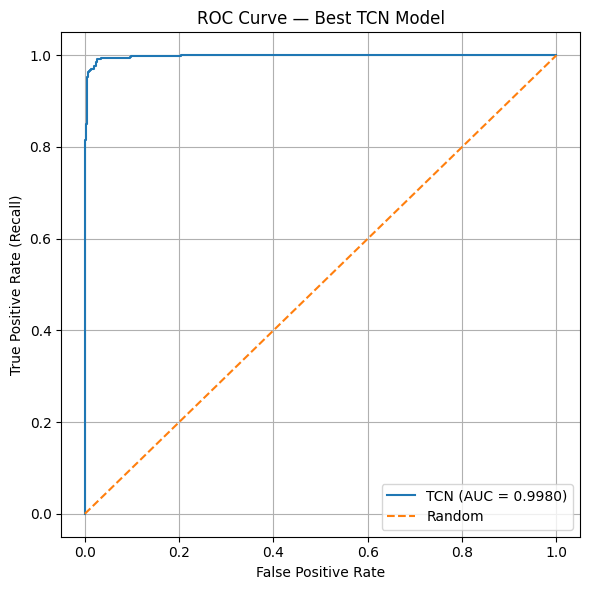

In [85]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"TCN (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Best TCN Model")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

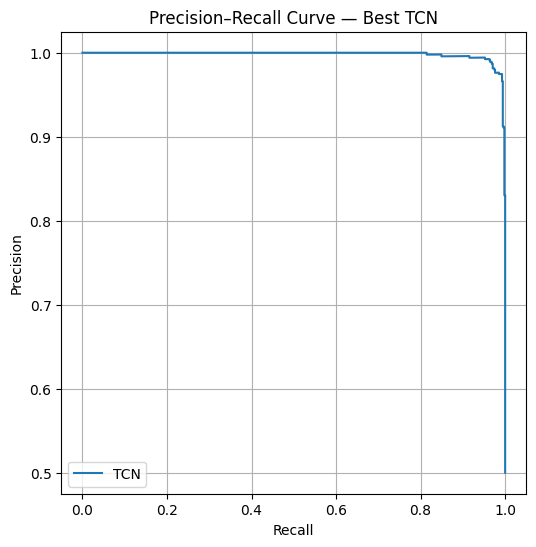

In [88]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(test_labels, test_probs)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label="TCN")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve — Best TCN")
plt.grid(True)
plt.legend()
plt.show()

In [86]:
RUN_NAME = f"tcn_threshold_tuned_{feature_key}"

METRIC_DIR.mkdir(parents=True, exist_ok=True)

metric_path = METRIC_DIR / f"{RUN_NAME}_test.json"

with open(metric_path, "w") as f:
    json.dump(test_metrics_threshold_tuned, f, indent=2)

print("Saved threshold-tuned metrics:", metric_path)

Saved threshold-tuned metrics: artifacts/metrics/tcn_threshold_tuned_4db0f011b9c0_test.json


## 13) Model registry summary

This gives you a reusable summary table across multiple saved models.

In [87]:

metric_files = sorted(METRIC_DIR.glob("*_test.json"))
rows = []
for fp in metric_files:
    metrics = json.load(open(fp))
    metrics["model_file"] = fp.name
    rows.append(metrics)

summary_df = pd.DataFrame(rows)
summary_df = summary_df[[
    "model_file",
    "accuracy",
    "precision_fake",
    "recall_fake",
    "f1_fake",
    "roc_auc",
    "false_positive_rate_human_as_fake",
    "tn", "fp", "fn", "tp"
]] if not summary_df.empty else pd.DataFrame()

summary_df

,model_file,accuracy,precision_fake,recall_fake,f1_fake,roc_auc,false_positive_rate_human_as_fake,tn,fp,fn,tp
0,cnn_bilstm_attention_4db0f011b9c0_flatten_test...,0.714154,0.894915,0.485294,0.629321,0.800626,0.056985,513,31,280,264
1,cnn_transformer_4db0f011b9c0_flatten_test.json,0.690257,0.968326,0.393382,0.559477,0.837015,0.012868,537,7,330,214
2,se_resnet_mfcc_4db0f011b9c0_flatten_test.json,0.818934,0.865263,0.755515,0.806673,0.895119,0.117647,480,64,133,411
3,tcn_4db0f011b9c0_flatten_test.json,0.968750,0.994186,0.943015,0.967925,0.998020,0.005515,541,3,31,513
4,tcn_hpo_4db0f011b9c0_test.json,0.933824,0.962745,0.902574,0.931689,0.989613,0.034926,525,19,53,491
5,tcn_threshold_tuned_4db0f011b9c0_test.json,0.978860,0.976234,0.981618,0.978918,0.998020,0.023897,531,13,10,534


## Plots

### Imports, helpers

In [65]:
!pip install matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/32/91/d024616abdba99e83120e07a20658976f6a343646710760c4a51df126029/matplotlib-3.10.9-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.0 MB/s eta 0:00:00
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/cc/8f/ec6289987824b29529d0dfda0d74a07cec60e54b9c92f3c9da4c0ac732de/contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from https://files.pythonhosted.org/packages/9b/8a/99c8b3c3888c5c474c08dbfd7c8899786de9604b727fcefb055b42c84bba/fonttools-4.62.1-cp312-cp312-manylinux2014_x86

In [66]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

metric_files = sorted(METRIC_DIR.glob("*_test.json"))

rows = []
for fp in metric_files:
    metrics = json.load(open(fp))
    metrics["model_file"] = fp.name
    rows.append(metrics)

summary_df = pd.DataFrame(rows)

summary_df = summary_df[[
    "model_file",
    "accuracy",
    "precision_fake",
    "recall_fake",
    "f1_fake",
    "roc_auc",
    "false_positive_rate_human_as_fake",
    "tn", "fp", "fn", "tp"
]].sort_values("f1_fake", ascending=False).reset_index(drop=True)

summary_df

,model_file,accuracy,precision_fake,recall_fake,f1_fake,roc_auc,false_positive_rate_human_as_fake,tn,fp,fn,tp
0,tcn_threshold_tuned_4db0f011b9c0_test.json,0.978860,0.976234,0.981618,0.978918,0.998020,0.023897,531,13,10,534
1,tcn_4db0f011b9c0_flatten_test.json,0.968750,0.994186,0.943015,0.967925,0.998020,0.005515,541,3,31,513
2,tcn_hpo_4db0f011b9c0_test.json,0.933824,0.962745,0.902574,0.931689,0.989613,0.034926,525,19,53,491
3,se_resnet_mfcc_4db0f011b9c0_flatten_test.json,0.818934,0.865263,0.755515,0.806673,0.895119,0.117647,480,64,133,411
4,cnn_bilstm_attention_4db0f011b9c0_flatten_test...,0.714154,0.894915,0.485294,0.629321,0.800626,0.056985,513,31,280,264
5,cnn_transformer_4db0f011b9c0_flatten_test.json,0.690257,0.968326,0.393382,0.559477,0.837015,0.012868,537,7,330,214


### Bar plots for all key metrics

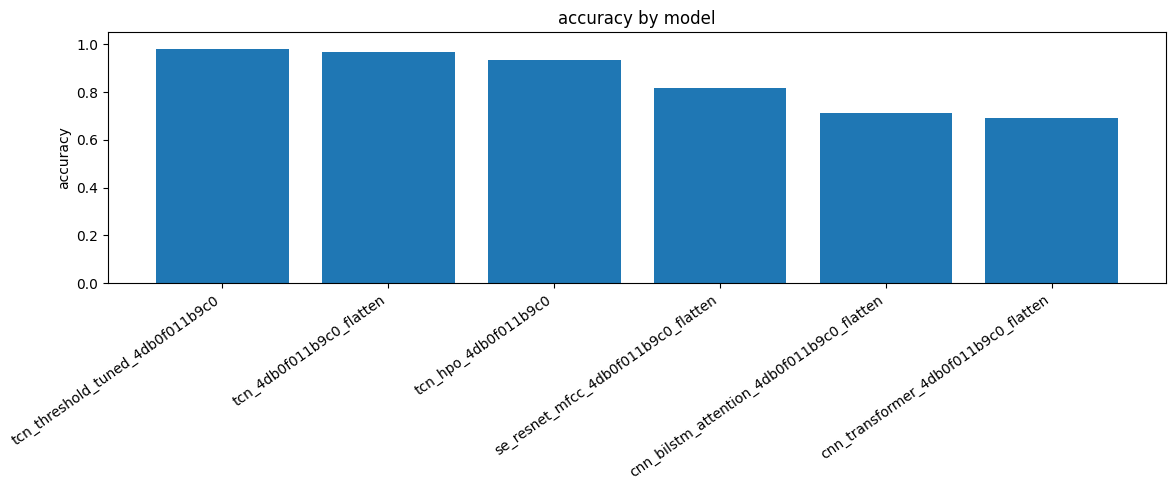

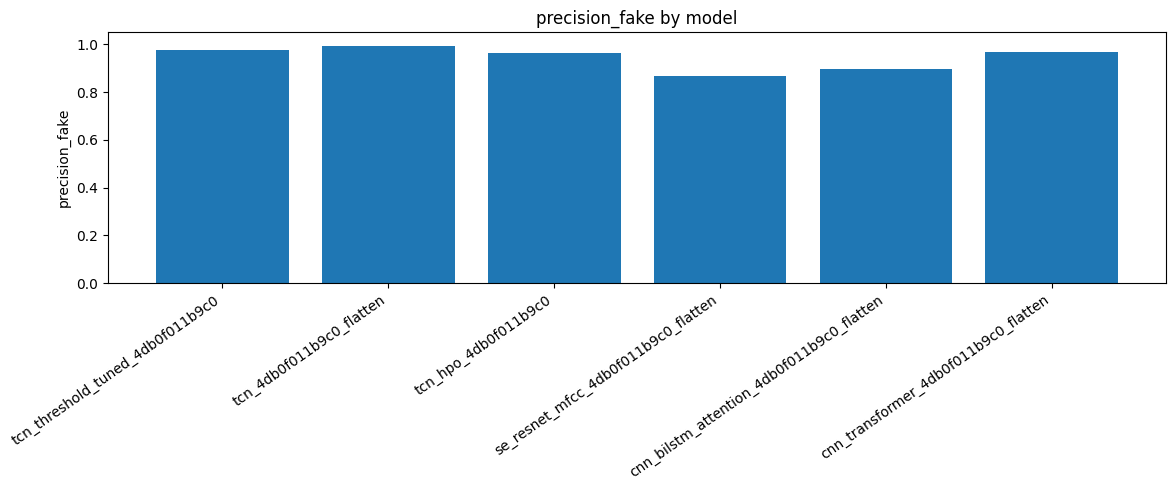

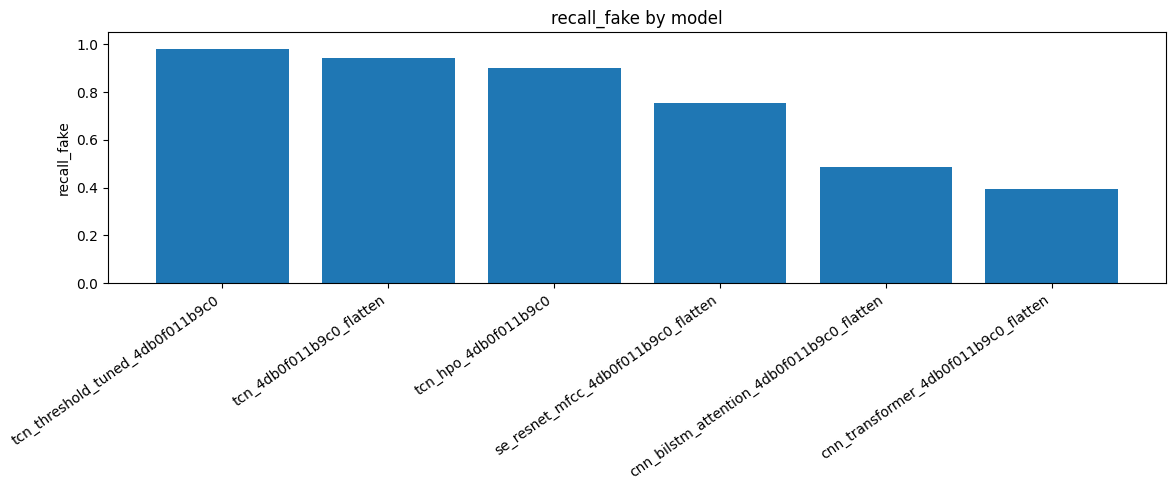

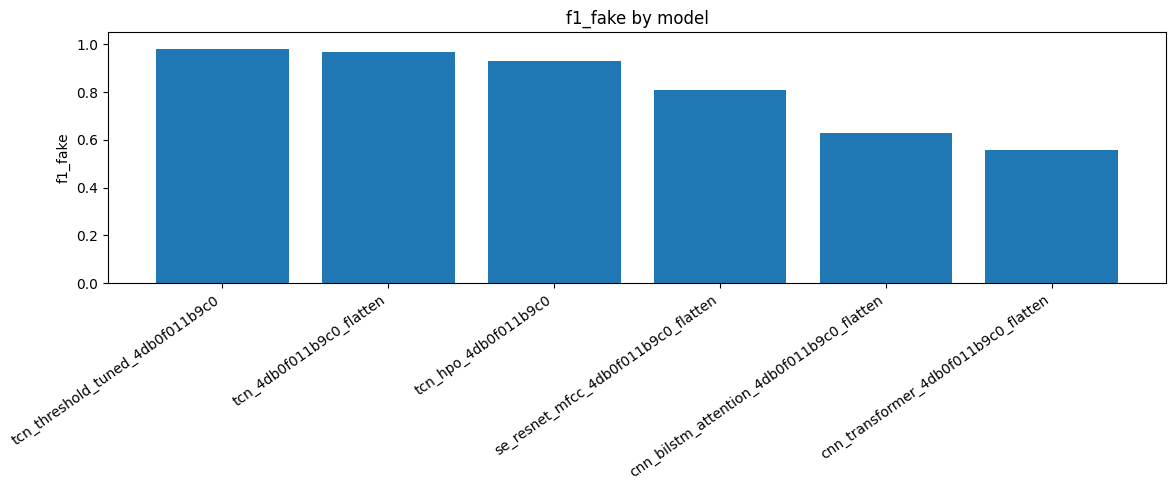

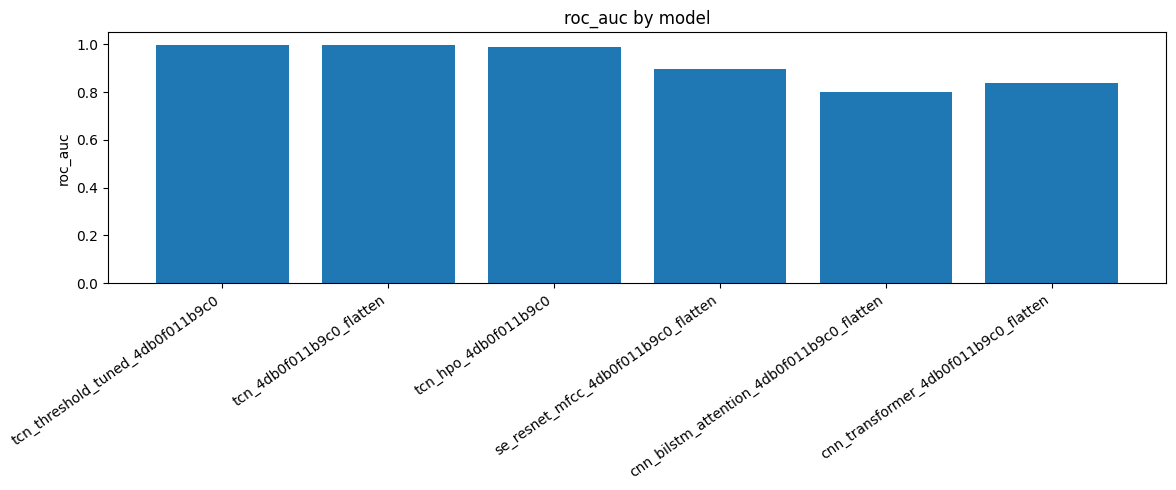

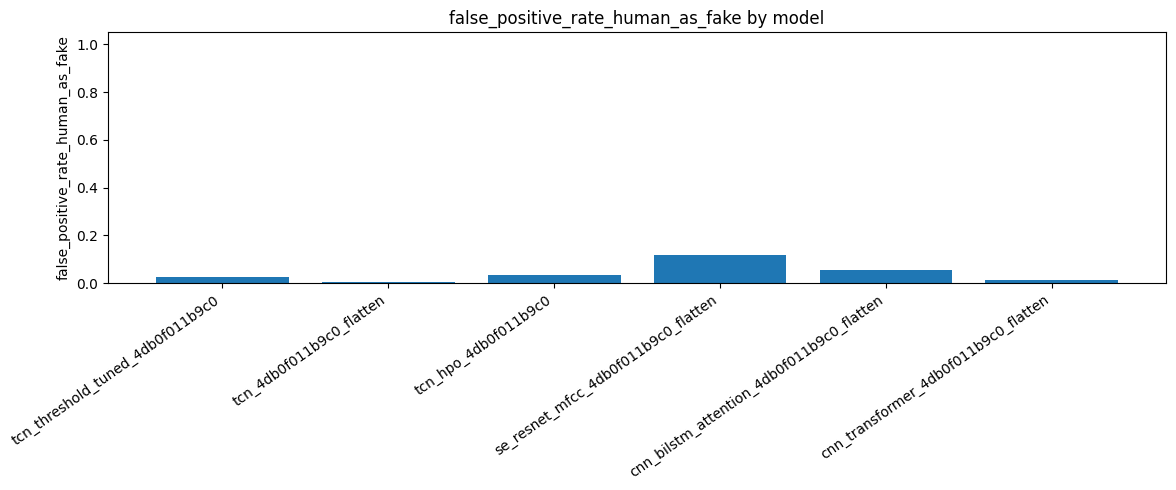

In [67]:
plot_df = summary_df.copy()
plot_df["model_short"] = plot_df["model_file"].str.replace("_test.json", "", regex=False)

metrics_to_plot = [
    "accuracy",
    "precision_fake",
    "recall_fake",
    "f1_fake",
    "roc_auc",
    "false_positive_rate_human_as_fake"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["model_short"], plot_df[metric])
    plt.xticks(rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} by model")
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

### Confusion Metrics

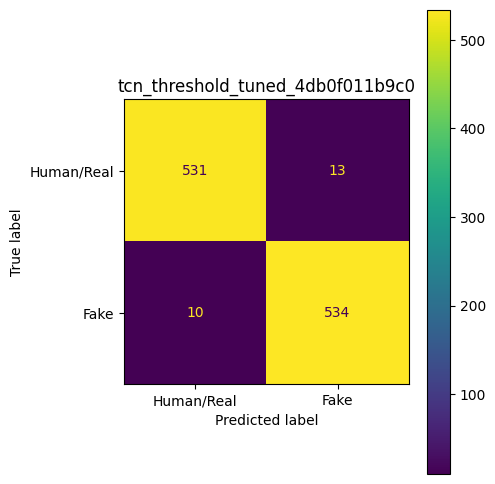

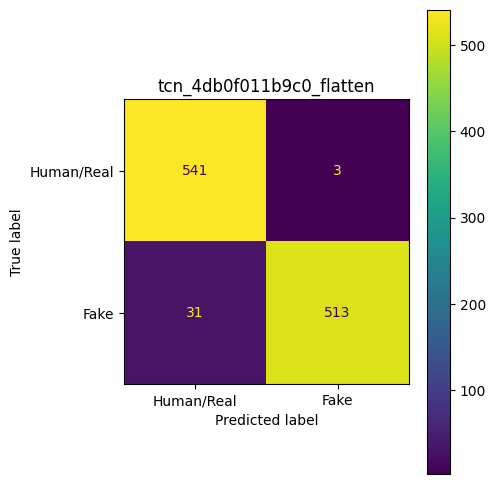

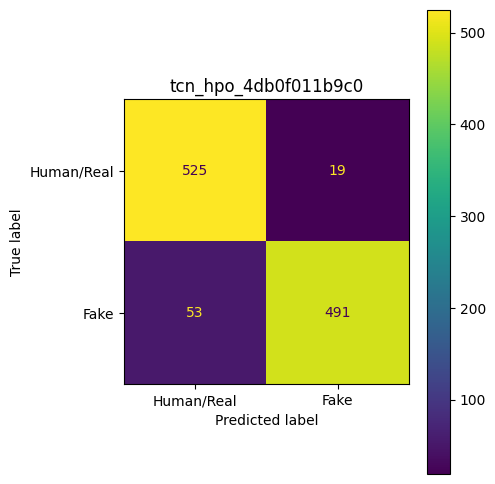

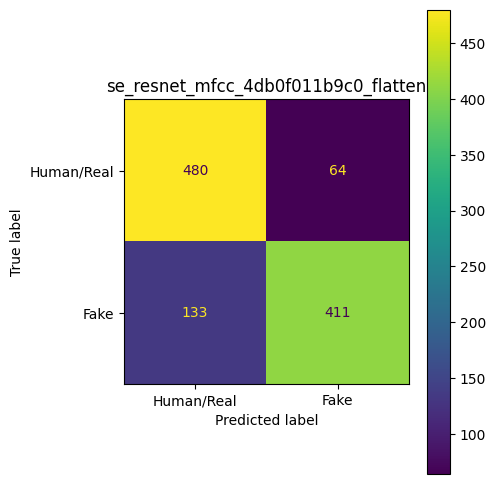

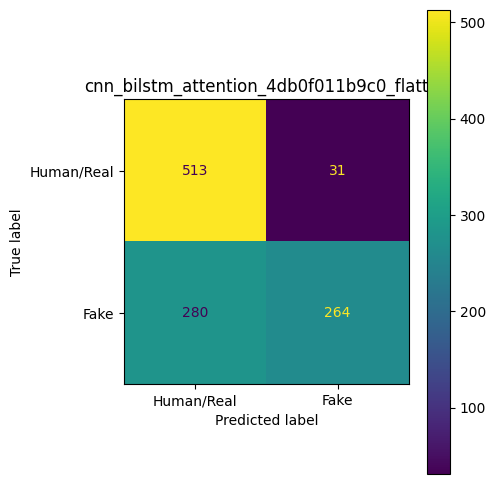

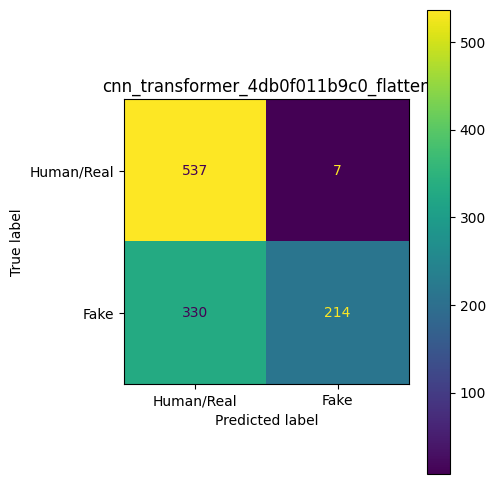

In [68]:
for _, row in summary_df.iterrows():
    cm = np.array([
        [row["tn"], row["fp"]],
        [row["fn"], row["tp"]]
    ])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Human/Real", "Fake"]
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(row["model_file"].replace("_test.json", ""))
    plt.tight_layout()
    plt.show()

### Save plots to folder

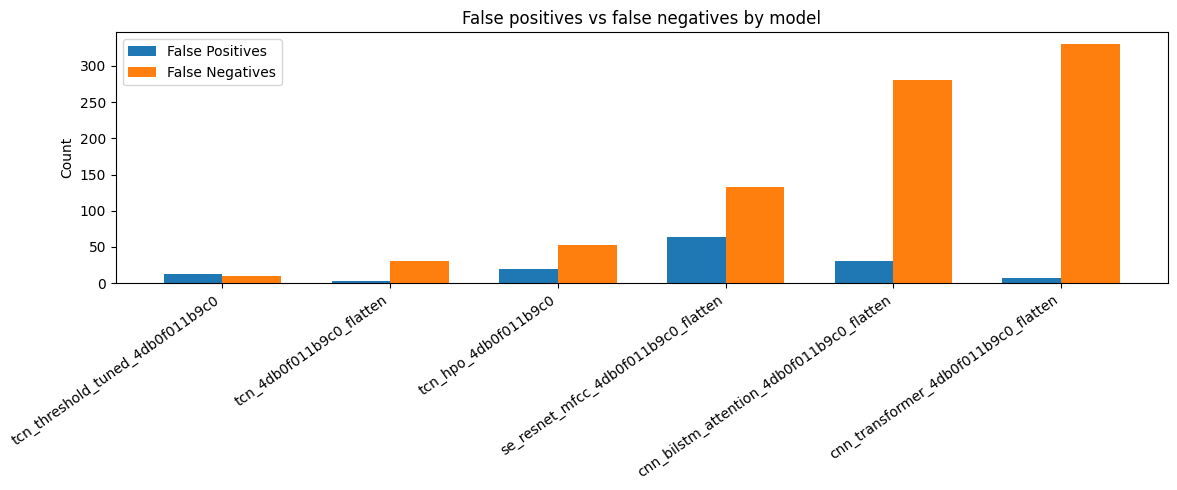

In [70]:
error_df = summary_df.copy()
error_df["model_short"] = error_df["model_file"].str.replace("_test.json", "", regex=False)

x = np.arange(len(error_df))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width/2, error_df["fp"], width, label="False Positives")
plt.bar(x + width/2, error_df["fn"], width, label="False Negatives")

plt.xticks(x, error_df["model_short"], rotation=35, ha="right")
plt.ylabel("Count")
plt.title("False positives vs false negatives by model")
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / "fp_fn_by_model.png", dpi=200, bbox_inches="tight")
plt.show()

### ROC + PR curves helper

In [78]:
PRED_DIR = Path("artifacts/predictions")

def find_prediction_files():
    files = sorted(PRED_DIR.glob("*test*.csv")) + sorted(PRED_DIR.glob("*test*.json"))
    return files

prediction_files = find_prediction_files()

print("Prediction files found:")
for f in prediction_files:
    print(f)

Prediction files found:


In [79]:
def load_prediction_file(fp):
    if fp.suffix == ".csv":
        df = pd.read_csv(fp)
    elif fp.suffix == ".json":
        df = pd.read_json(fp)
    else:
        raise ValueError(f"Unsupported file: {fp}")

    if "y_true" in df.columns:
        y_true = df["y_true"].values
    elif "label" in df.columns:
        y_true = df["label"].values
    else:
        raise ValueError(f"{fp} missing y_true/label column")

    if "prob_fake" in df.columns:
        probs = df["prob_fake"].values
    elif "prob_1" in df.columns:
        probs = df["prob_1"].values
    else:
        raise ValueError(f"{fp} missing prob_fake/prob_1 column")

    return y_true, probs


if len(prediction_files) == 0:
    print("No prediction probability files found in:", PRED_DIR)
    print("ROC/PR curves need per-sample probabilities, not only summary metrics.")
else:
    plt.figure(figsize=(8, 6))

    for fp in prediction_files:
        y_true, probs = load_prediction_file(fp)
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc = auc(fpr, tpr)

        label = fp.stem.replace("_test", "")
        plt.plot(fpr, tpr, label=f"{label} AUC={roc_auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate / Recall")
    plt.title("ROC Curves")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))

    for fp in prediction_files:
        y_true, probs = load_prediction_file(fp)
        precision, recall, _ = precision_recall_curve(y_true, probs)
        pr_auc = auc(recall, precision)

        label = fp.stem.replace("_test", "")
        plt.plot(recall, precision, label=f"{label} AUC={pr_auc:.3f}")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curves")
    plt.legend()
    plt.tight_layout()
    plt.show()

No prediction probability files found in: artifacts/predictions
ROC/PR curves need per-sample probabilities, not only summary metrics.


## 14) How to reuse this notebook for other models

Use the same saved artifacts:
- `artifacts/manifests/*.csv`
- `artifacts/features/mfcc_<feature_key>/`
- `artifacts/arrays/mfcc_<feature_key>_<view>/`
- `artifacts/models/scaler_<...>.joblib`

Then add a new training cell for another model, for example:
- Linear SVM
- RBF SVM
- Random Forest
- MLP
- CNN on MFCC maps

Only the new model-training stage runs. The heavy preprocessing stays cached.

In [ ]:
# Example stub for another model
# from sklearn.svm import LinearSVC
# svm = LinearSVC(C=1.0, random_state=SEED)
# svm.fit(X_train_scaled, y_train)
# Save the model and metrics with the same pattern as above.